# Operator and momentum resolved spectral functions

`h.get_kdos_bands(operator=...)` weights the momentum-resolved spectral function
$A(k,\omega)$ by the expectation value of a chosen operator in each eigenstate -- e.g. a spin
operator, giving a spin-resolved spectral function that reveals which branch of a spin-split band
structure carries the spectral weight at each $(k,\omega)$. Rashba spin-orbit coupling,
$\alpha(\boldsymbol\sigma\times\mathbf k)\cdot\hat z$, only ever involves $\sigma_x,\sigma_y$, so
its spin texture is locked entirely in-plane, perpendicular to $\mathbf k$ -- $\langle S_z\rangle$
is exactly zero for every eigenstate by construction, while the in-plane operator `"sx"` reveals
the actual spin-momentum locking.

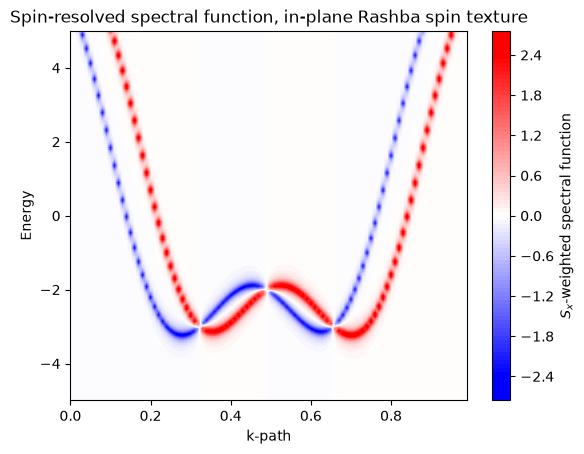

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.triangular_lattice()
h = g.get_hamiltonian()
h.add_rashba(0.5)

nk = 100
energies = np.linspace(-5,5,150)
kx,ky,d = h.get_kdos_bands(operator="sx",nk=nk,energies=energies,delta=0.1)
dgrid = d.reshape(nk,len(energies)).T
vmax = np.percentile(np.abs(dgrid),99)

plt.contourf(np.unique(kx),energies,dgrid,levels=100,cmap="bwr",vmin=-vmax,vmax=vmax)
plt.colorbar(label="$S_x$-weighted spectral function")
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title("Spin-resolved spectral function, in-plane Rashba spin texture")
plt.show()